In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv("../data/cardio_train.csv", sep=';')
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [41]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [42]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [44]:
df.drop(columns=['id'], inplace=True)

In [45]:
df['age'] = (df['age'] / 365).astype(int)

In [46]:
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,47,1,156,56.0,100,60,1,1,0,0,0,0


In [47]:
df.describe()


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,52.840671,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,6.766774,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,29.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,53.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,58.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,64.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [48]:
# Remove extreme height values (assume normal range 140-210 cm)

df = df[(df['height'] >= 140) & (df['height'] <= 210)]

In [49]:
# Remove extreme weight values (assume normal range 40-180 kg)

df = df[(df['weight'] >= 40) & (df['weight'] <= 180)]


In [50]:
# Remove extreme systolic BP values (normal range: 90-180)

df = df[(df['ap_hi'] >= 90) & (df['ap_hi'] <= 180)]

In [51]:
# Remove extreme diastolic BP values (normal range: 60-120)

df = df[(df['ap_lo'] >= 60) & (df['ap_lo'] <= 120)]

In [52]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,68013.000000,68013.000000,68013.000000,68013.000000,68013.000000,68013.000000,68013.000000,68013.000000,68013.000000,68013.000000,68013.000000,68013.000000
mean,52.823137,1.348874,164.480849,74.117733,126.446679,81.271257,1.363533,1.225207,0.087748,0.053166,0.803611,0.493803
std,6.768373,0.476618,7.789140,14.193477,15.955273,9.140202,0.678310,0.571319,0.282930,0.224367,0.397269,0.499965
min,29.000000,1.000000,140.000000,40.000000,90.000000,60.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,53.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,58.000000,2.000000,170.000000,82.000000,140.000000,90.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,64.000000,2.000000,207.000000,180.000000,180.000000,120.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [53]:
df.shape


(68013, 12)

In [54]:
df.nunique()


age             28
gender           2
height          60
weight         256
ap_hi           86
ap_lo           58
cholesterol      3
gluc             3
smoke            2
alco             2
active           2
cardio           2
dtype: int64

In [55]:
df.isnull().sum()


age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

C:\Users\asusr\AppData\Local\Temp\ipykernel_23212\2690266410.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["cardio"], palette="coolwarm")


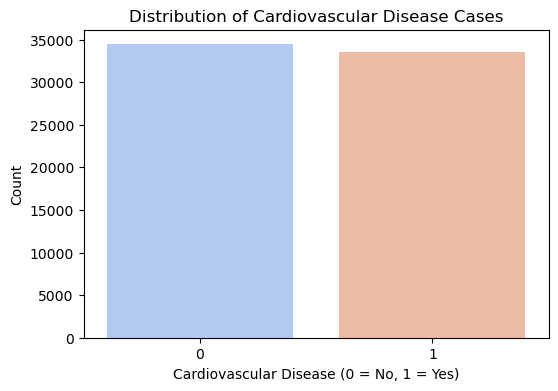

In [56]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["cardio"], palette="coolwarm")
plt.title("Distribution of Cardiovascular Disease Cases")
plt.xlabel("Cardiovascular Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

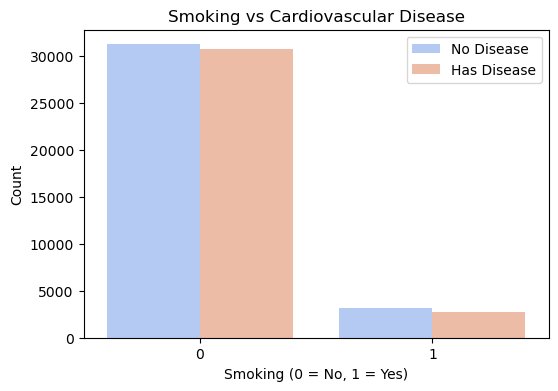

In [57]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["smoke"], hue=df["cardio"], palette="coolwarm")
plt.title("Smoking vs Cardiovascular Disease")
plt.xlabel("Smoking (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.legend(["No Disease", "Has Disease"])
plt.show()

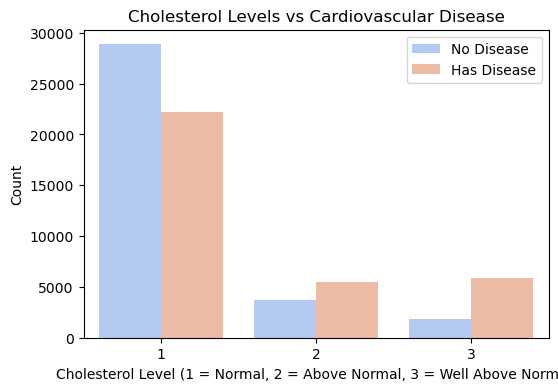

In [58]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["cholesterol"], hue=df["cardio"], palette="coolwarm")
plt.title("Cholesterol Levels vs Cardiovascular Disease")
plt.xlabel("Cholesterol Level (1 = Normal, 2 = Above Normal, 3 = Well Above Normal)")
plt.ylabel("Count")
plt.legend(["No Disease", "Has Disease"])
plt.show()

C:\Users\asusr\AppData\Local\Temp\ipykernel_23212\805658500.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["cardio"], y=df["ap_hi"], palette="coolwarm")


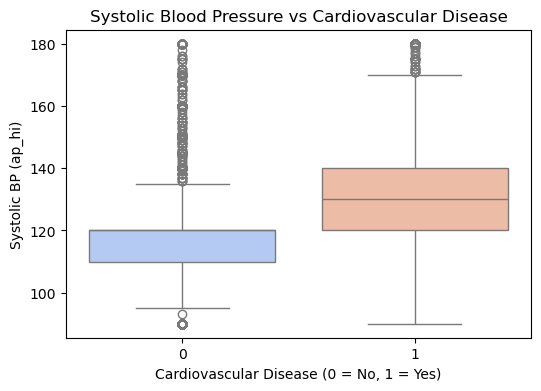

In [59]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["cardio"], y=df["ap_hi"], palette="coolwarm")
plt.title("Systolic Blood Pressure vs Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease (0 = No, 1 = Yes)")
plt.ylabel("Systolic BP (ap_hi)")
plt.show()

C:\Users\asusr\AppData\Local\Temp\ipykernel_23212\1101086806.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["cardio"], y=df["ap_lo"], palette="coolwarm")


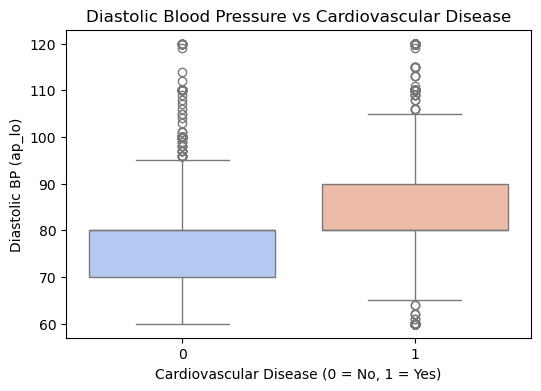

In [60]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["cardio"], y=df["ap_lo"], palette="coolwarm")
plt.title("Diastolic Blood Pressure vs Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease (0 = No, 1 = Yes)")
plt.ylabel("Diastolic BP (ap_lo)")
plt.show()

In [61]:
df.corr()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
age,1.000000,-0.024117,-0.087401,0.054904,0.211596,0.155891,0.154970,0.098614,-0.048230,-0.029032,-0.010856,0.238966
gender,-0.024117,1.000000,0.523181,0.156623,0.060439,0.065820,-0.037381,-0.021907,0.337781,0.170833,0.005196,0.005988
height,-0.087401,0.523181,1.000000,0.310093,0.016558,0.034091,-0.057177,-0.021642,0.196254,0.098101,-0.010483,-0.013680
weight,0.054904,0.156623,0.310093,1.000000,0.267932,0.249650,0.140411,0.106139,0.067344,0.066882,-0.017299,0.178117
ap_hi,0.211596,0.060439,0.016558,0.267932,1.000000,0.731572,0.195402,0.093033,0.025732,0.032422,-0.001734,0.433993
ap_lo,0.155891,0.065820,0.034091,0.249650,0.731572,1.000000,0.161659,0.073354,0.023448,0.035771,-0.001635,0.342895
cholesterol,0.154970,-0.037381,-0.057177,0.140411,0.195402,0.161659,1.000000,0.450273,0.009763,0.034149,0.008606,0.220712
gluc,0.098614,-0.021907,-0.021642,0.106139,0.093033,0.073354,0.450273,1.000000,-0.006098,0.009022,-0.008221,0.088507
smoke,-0.048230,0.337781,0.196254,0.067344,0.025732,0.023448,0.009763,-0.006098,1.000000,0.338329,0.024730,-0.016632
alco,-0.029032,0.170833,0.098101,0.066882,0.032422,0.035771,0.034149,0.009022,0.338329,1.000000,0.024437,-0.008859


<Axes: >

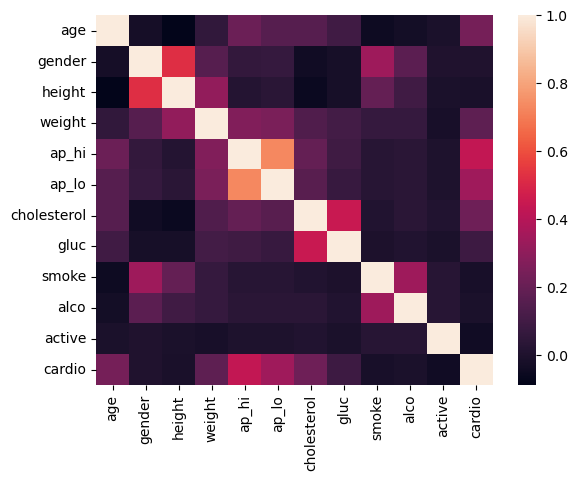

In [62]:
sns.heatmap(df.corr())


In [63]:
df.to_csv("../data/pre_proccesed_data.csv",index=False)